# Few-Shot Target Adaptation

In [1]:
!pip install transformers datasets torch scikit-learn pandas numpy matplotlib seaborn accelerate -q

In [2]:
CATEGORIES = [
    "Electronics",
    "Books",
    "Clothing_Shoes_and_Jewelry",
    "Home_and_Kitchen",
    "Sports_and_Outdoors",
]

CATEGORY_LABELS = [
    "Electronics", "Books", "Clothing", "Home & Kitchen", "Sports"
]

FILE_STEMS = {
    "Electronics":               "electronics",
    "Books":                     "books",
    "Clothing_Shoes_and_Jewelry": "clothing",
    "Home_and_Kitchen":           "home_kitchen",
    "Sports_and_Outdoors":        "sports",
}

FEW_SHOT_SIZES      = [16, 32, 64]
FEW_SHOT_EPOCHS     = 3
FEW_SHOT_LR         = 1e-5
FEW_SHOT_BATCH_SIZE = 8
MAX_LENGTH          = 128
EVAL_BATCH_SIZE     = 32
RANDOM_SEED         = 104
DRIVE_BASE          = "/content/drive/MyDrive/cross-category-sentiment-robustness"

In [3]:
import os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import (
    RobertaTokenizerFast, RobertaForSequenceClassification,
    TrainingArguments, Trainer,
)
from sklearn.metrics import accuracy_score, f1_score
from google.colab import drive

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

drive.mount("/content/drive")
DATA_DIR    = f"{DRIVE_BASE}/data"
MODELS_DIR  = f"{DRIVE_BASE}/models"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cuda
Mounted at /content/drive


## 1  Identify worst cross-category pair

In [4]:
rob_acc = pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix.csv", index_col=0)

m = rob_acc.values.astype(float)
n = m.shape[0]
masked = np.ma.masked_array(m, np.eye(n, dtype=bool))
si, ti = np.unravel_index(masked.argmin(), m.shape)

SOURCE_CAT = CATEGORIES[si]
TARGET_CAT = CATEGORIES[ti]
SRC_STEM   = FILE_STEMS[SOURCE_CAT]
TGT_STEM   = FILE_STEMS[TARGET_CAT]

ZERO_SHOT_ACC = float(m[si, ti])

print(f"Worst cross-category pair:")
print(f"  Source: {CATEGORY_LABELS[si]}")
print(f"  Target: {CATEGORY_LABELS[ti]}")
print(f"  Zero-shot accuracy: {ZERO_SHOT_ACC:.3f}")

Worst cross-category pair:
  Source: Books
  Target: Sports
  Zero-shot accuracy: 0.515


## 2  Dataset utilities

In [5]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


def sample_few_shot(df_train: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    """Sample n/2 positives + n/2 negatives.

    Each call uses seed directly so results are reproducible but each shot-size
    draws an independent balanced sample (not a superset of the smaller sizes).
    """
    half = n // 2
    pos = df_train[df_train["label"] == 1].sample(half, random_state=seed)
    neg = df_train[df_train["label"] == 0].sample(half, random_state=seed)
    return pd.concat([pos, neg]).sample(frac=1, random_state=seed).reset_index(drop=True)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="macro"),
    }

## 3  Load source model & target splits

In [6]:
src_model_dir = f"{MODELS_DIR}/roberta_{SRC_STEM}"
tokenizer = RobertaTokenizerFast.from_pretrained(src_model_dir)

df_tgt_train = pd.read_csv(f"{DATA_DIR}/{TGT_STEM}_train.csv")
df_tgt_test  = pd.read_csv(f"{DATA_DIR}/{TGT_STEM}_test.csv")

df_tgt_train["text"] = df_tgt_train["text"].fillna("").astype(str)
df_tgt_test["text"]  = df_tgt_test["text"].fillna("").astype(str)

test_ds = ReviewDataset(df_tgt_test["text"], df_tgt_test["label"], tokenizer, MAX_LENGTH)

print(f"Target train: {len(df_tgt_train)} rows")
print(f"Target test:  {len(df_tgt_test)} rows")

Target train: 2400 rows
Target test:  600 rows


## 4  Few-shot adaptation loop

In [7]:
def adapt_and_evaluate(n_shots: int) -> dict:
    """Continue fine-tuning on n_shots target examples, evaluate on full target test set."""
    few_shot_df = sample_few_shot(df_tgt_train, n_shots, RANDOM_SEED)
    train_ds    = ReviewDataset(few_shot_df["text"], few_shot_df["label"], tokenizer, MAX_LENGTH)

    # Reload source checkpoint fresh each run to avoid cross-run contamination
    model = RobertaForSequenceClassification.from_pretrained(src_model_dir)

    save_dir = f"{MODELS_DIR}/roberta_fewshot_{SRC_STEM}_to_{TGT_STEM}_{n_shots}shot"
    fp16     = torch.cuda.is_available()

    args = TrainingArguments(
        output_dir=save_dir,
        num_train_epochs=FEW_SHOT_EPOCHS,
        per_device_train_batch_size=FEW_SHOT_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=FEW_SHOT_LR,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        fp16=fp16,
        seed=RANDOM_SEED,
        logging_steps=10,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        compute_metrics=compute_metrics,
        processing_class=tokenizer,       # Lab 6 pattern — current API in transformers>=4.46
    )

    print(f"\nAdapting with {n_shots} examples …")
    trainer.train()
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)

    out    = trainer.predict(test_ds)
    preds  = np.argmax(out.predictions, axis=-1)
    y_true = df_tgt_test["label"].values

    acc = accuracy_score(y_true, preds)
    f1  = f1_score(y_true, preds, average="macro")
    print(f"  {n_shots}-shot → acc={acc:.3f}  f1={f1:.3f}")
    return {"few_shot_size": n_shots, "accuracy": acc, "macro_f1": f1}


fewshot_rows = [{"few_shot_size": 0,
                 "accuracy":       ZERO_SHOT_ACC,
                 "macro_f1":       float(pd.read_csv(f"{RESULTS_DIR}/roberta_transfer_matrix_f1.csv",
                                                     index_col=0).iloc[si, ti])}]

for k in FEW_SHOT_SIZES:
    fewshot_rows.append(adapt_and_evaluate(k))

fewshot_df = pd.DataFrame(fewshot_rows)
fewshot_df.to_csv(f"{RESULTS_DIR}/fewshot_results.csv", index=False)

print("\nFew-shot results:")
print(fewshot_df.to_string(index=False))

Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]


Adapting with 16 examples …


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.721028,0.523333,0.458224
2,No log,0.719195,0.523333,0.455335
3,No log,0.718821,0.523333,0.455335


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  64-shot → acc=0.515  f1=0.509

Few-shot results:
 few_shot_size  accuracy  macro_f1
             0  0.515000  0.456398
            16  0.523333  0.455335
            32  0.530000  0.461496
            64  0.515000  0.509240


## 5  Visualisation — recovery curve

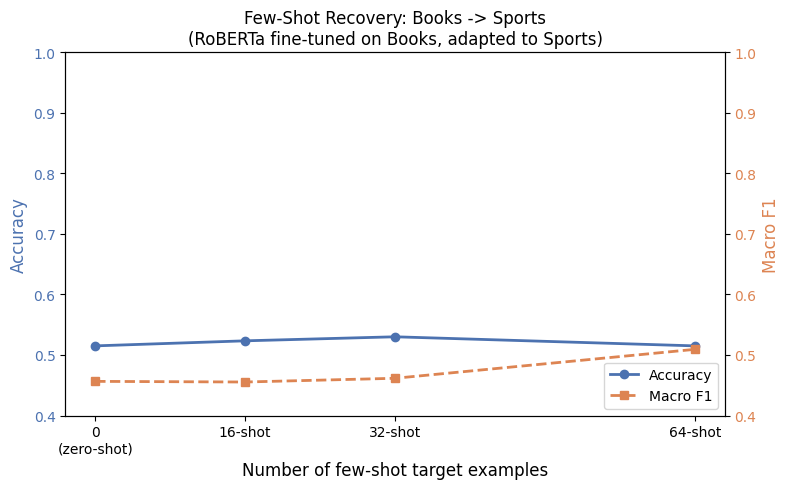

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))

x = fewshot_df["few_shot_size"].values

color_acc = "#4c72b0"
color_f1  = "#dd8452"

ax1.plot(x, fewshot_df["accuracy"],  marker="o", color=color_acc, linewidth=2, label="Accuracy")
ax1.set_xlabel("Number of few-shot target examples", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12, color=color_acc)
ax1.tick_params(axis="y", labelcolor=color_acc)
ax1.set_xticks(x)
ax1.set_xticklabels(["0\n(zero-shot)", "16-shot", "32-shot", "64-shot"])
ax1.set_ylim(0.4, 1.0)

ax2 = ax1.twinx()
ax2.plot(x, fewshot_df["macro_f1"], marker="s", color=color_f1,  linewidth=2, linestyle="--", label="Macro F1")
ax2.set_ylabel("Macro F1", fontsize=12, color=color_f1)
ax2.tick_params(axis="y", labelcolor=color_f1)
ax2.set_ylim(0.4, 1.0)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

title = (f"Few-Shot Recovery: {CATEGORY_LABELS[si]} -> {CATEGORY_LABELS[ti]}\n"
         f"(RoBERTa fine-tuned on {CATEGORY_LABELS[si]}, adapted to {CATEGORY_LABELS[ti]})")
plt.title(title, fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fewshot_recovery_curve.png", dpi=150)
plt.show()

## 6  Summary table

In [9]:
summary = fewshot_df.copy()
summary["few_shot_size"] = summary["few_shot_size"].apply(
    lambda x: "0 (zero-shot)" if x == 0 else f"{x}-shot"
)
summary.columns = ["Setting", "Accuracy", "Macro F1"]
summary["Accuracy"] = summary["Accuracy"].map("{:.3f}".format)
summary["Macro F1"] = summary["Macro F1"].map("{:.3f}".format)

print()
print(f"Few-shot adaptation summary")
print(f"Source: {CATEGORY_LABELS[si]}  ->  Target: {CATEGORY_LABELS[ti]}")
print()
print(summary.to_string(index=False))


Few-shot adaptation summary
Source: Books  ->  Target: Sports

      Setting Accuracy Macro F1
0 (zero-shot)    0.515    0.456
      16-shot    0.523    0.455
      32-shot    0.530    0.461
      64-shot    0.515    0.509
